# Entrenamiento de modelos de clasificación binaria: Random Forest vs XGBoost
### Predicción de `VENTAJA` a partir del estado del tablero y la carta jugada

Este notebook sigue 5 secciones:

1. Análisis exploratorio de datos (EDA)
2. Preprocesamiento de los datos
3. Entrenamiento de los modelos (Random Forest y XGBoost)
4. Comparación de métricas para escoger el mejor modelo
5. Tuning del modelo ganador

In [3]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve,
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [4]:
# Carga de datos
# Ajustar la ruta si el archivo se encuentra en otra ubicación
DATA_PATH = "dataset2.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (2907, 21)


,C1A,C1B,C1C,C2A,C2B,C2C,C3A,C3B,C3C,T1A,...,T1C,T2A,T2B,T2C,T3A,T3B,T3C,RONDA,TURNO,VENTAJA
0,0,0,1,0,0,2,0,4,1,0,...,0,0,0,0,0,0,0,1,1,1
1,0,0,4,1,0,0,2,1,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
2,1,0,1,0,3,0,0,3,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
3,2,0,0,1,0,3,2,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
4,1,4,0,2,0,0,1,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0


## 1. Análisis exploratorio de datos (EDA)

### 1.1 Estructura general, tipos de datos, faltantes y duplicados

In [5]:
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores faltantes totales:", df.isna().sum().sum())
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
df.describe().T

Tipos de datos:
C1A        int64
C1B        int64
C1C        int64
C2A        int64
C2B        int64
C2C        int64
C3A        int64
C3B        int64
C3C        int64
T1A        int64
T1B        int64
T1C        int64
T2A        int64
T2B        int64
T2C        int64
T3A        int64
T3B        int64
T3C        int64
RONDA      int64
TURNO      int64
VENTAJA    int64
dtype: object

Valores faltantes totales: 0
Filas duplicadas (todas las columnas): 0


,count,mean,std,min,25%,50%,75%,max
C1A,2907.0,0.640179,0.942903,0.0,0.0,0.0,1.0,4.0
C1B,2907.0,0.974544,1.177344,0.0,0.0,0.0,2.0,4.0
C1C,2907.0,0.568627,0.889848,0.0,0.0,0.0,1.0,4.0
C2A,2907.0,0.949432,1.174922,0.0,0.0,0.0,2.0,4.0
C2B,2907.0,1.750946,1.507915,0.0,0.0,3.0,3.0,4.0
C2C,2907.0,0.964912,1.171234,0.0,0.0,0.0,2.0,4.0
C3A,2907.0,0.582731,0.902481,0.0,0.0,0.0,1.0,4.0
C3B,2907.0,0.951840,1.154192,0.0,0.0,0.0,2.0,4.0
C3C,2907.0,0.616787,0.921768,0.0,0.0,0.0,1.0,4.0
T1A,2907.0,-0.392501,1.359775,-4.0,-1.0,0.0,0.0,3.0


### 1.2 Validación de las reglas del juego

Se valida que las variables de carta (`C1A...C3C`) cumplan las reglas descritas:
- La suma de las 9 posiciones de carta debe ser siempre 8.
- Exactamente 4 posiciones deben tener valores distintos de 0 (con valores del 1 al 4).

Se valida que las variables de tablero (`T1A...T3C`) cumplan la regla de consistencia:
- Las posiciones del tablero no deben sobrepasar el rango de (-6,6).

In [6]:
card_cols = ["C1A","C1B","C1C","C2A","C2B","C2C","C3A","C3B","C3C"]

card_sum = df[card_cols].sum(axis=1)
n_nonzero = (df[card_cols] != 0).sum(axis=1)

print("Filas con suma de carta != 8:", (card_sum != 8).sum())
print("Filas con cantidad de posiciones no-cero != 4:", (n_nonzero != 4).sum())

Filas con suma de carta != 8: 0
Filas con cantidad de posiciones no-cero != 4: 0


In [7]:
board_cols = ["T1A","T1B","T1C","T2A","T2B","T2C","T3A","T3B","T3C"]

out_of_range = (df[board_cols] < -6).sum(axis=1) + (df[board_cols] > 6).sum(axis=1)
print("Filas con valores fuera de rango de -6 a 6:", out_of_range.sum())

Filas con valores fuera de rango de -6 a 6: 0


### 1.3 Distribución de `RONDA` y `TURNO`

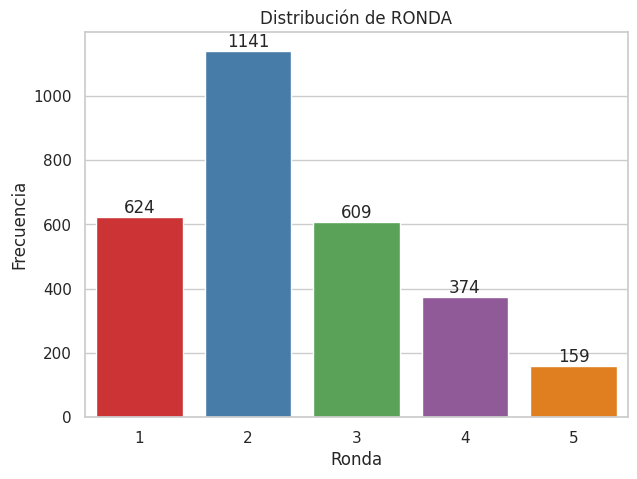

In [8]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=df["RONDA"], hue=df["RONDA"], palette="Set1", legend=False)
plt.title("Distribución de RONDA")
plt.xlabel("Ronda")
plt.ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

In [9]:
print(df["RONDA"].value_counts())
print()
print("Proporción de clases:")
print(df["RONDA"].value_counts(normalize=True))

RONDA
2    1141
1     624
3     609
4     374
5     159
Name: count, dtype: int64

Proporción de clases:
RONDA
2    0.392501
1    0.214654
3    0.209494
4    0.128655
5    0.054696
Name: proportion, dtype: float64


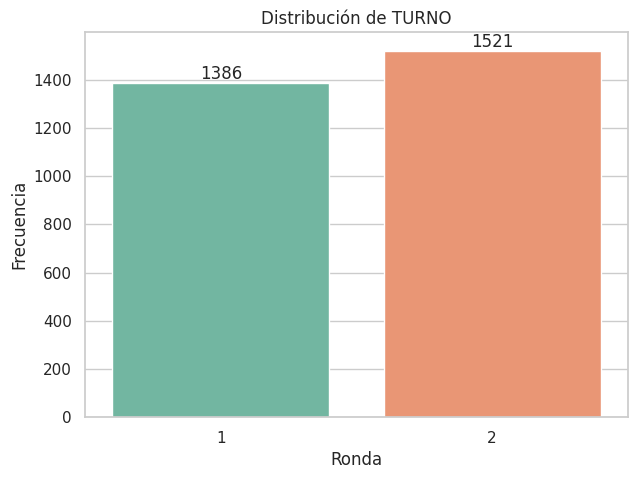

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=df["TURNO"], hue=df["TURNO"], palette="Set2", legend=False)
plt.title("Distribución de TURNO")
plt.xlabel("Ronda")
plt.ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

In [11]:
print(pd.crosstab(df["RONDA"], df["TURNO"]))

TURNO    1    2
RONDA          
1       13  611
2      691  450
3      352  257
4      210  164
5      120   39


### 1.4 Distribución de la variable objetivo `VENTAJA`

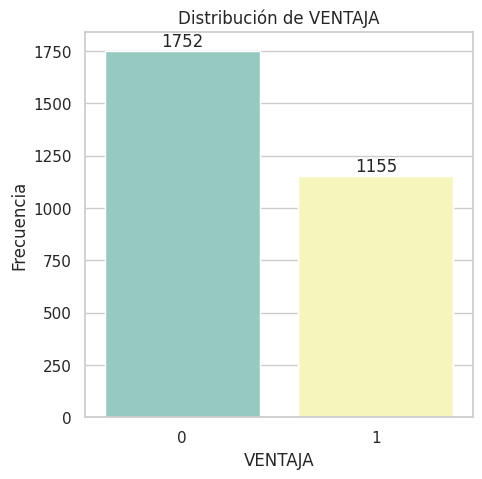

VENTAJA
0    1752
1    1155
Name: count, dtype: int64

Proporción de clases:
VENTAJA
0    0.602683
1    0.397317
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(5, 5))
ax = sns.countplot(x=df["VENTAJA"], hue=df["VENTAJA"], palette="Set3", legend=False)
plt.title("Distribución de VENTAJA")
plt.xlabel("VENTAJA")
plt.ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df["VENTAJA"].value_counts())
print()
print("Proporción de clases:")
print(df["VENTAJA"].value_counts(normalize=True))

### 1.5 Distribución de las posiciones de carta

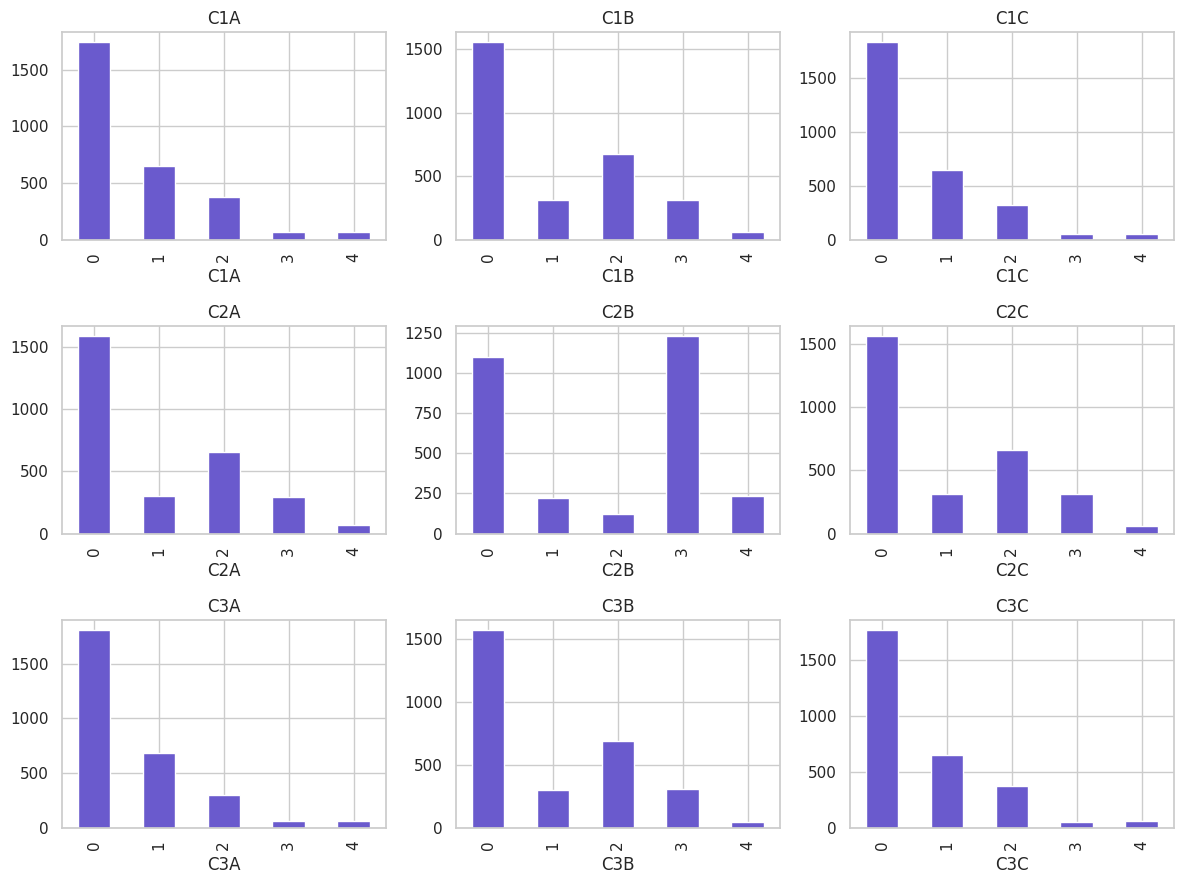

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, col in zip(axes.ravel(), card_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="slateblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.6 Multicolinealidad entre variables del tablero (`T*`)

Las variables de tablero comparten restricciones de suma entre celdas, por lo que es esperable que existan correlaciones fuertes entre algunas de ellas. Se documenta con un mapa de calor; no se eliminan variables, pero es importante tenerlo presente al interpretar la importancia de variables.

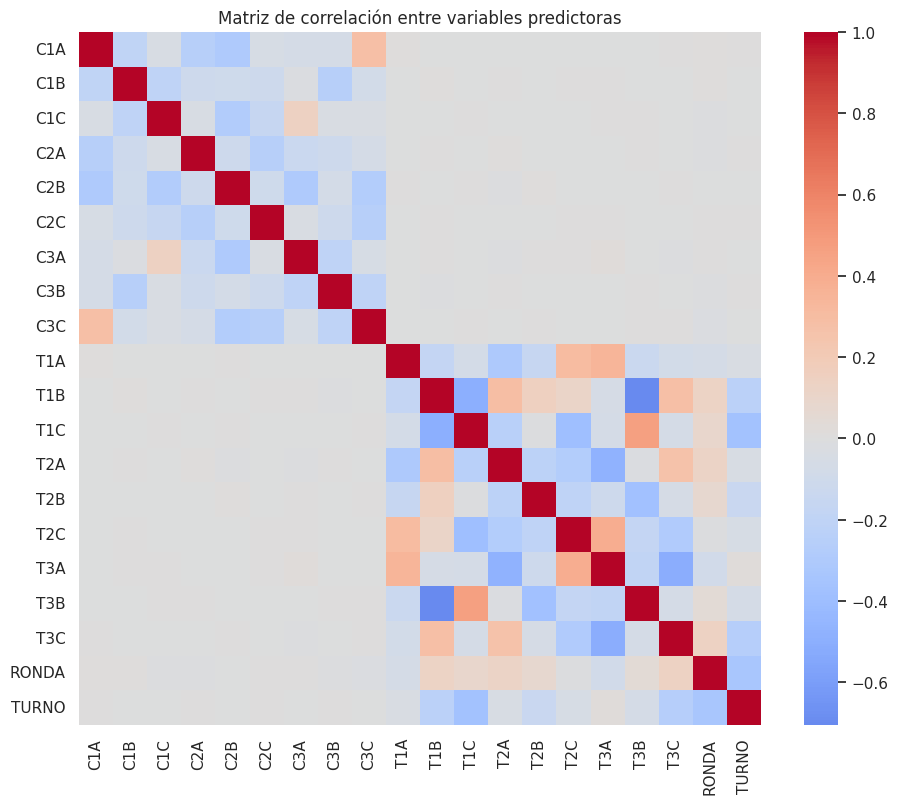

,var_1,var_2,correlacion
1,T1B,T3B,-0.705
2,T3A,T3C,-0.510
0,T1B,T1C,-0.501


In [14]:
feature_cols = [c for c in df.columns if c != "VENTAJA"]

plt.figure(figsize=(11, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables predictoras")
plt.show()

# Pares con correlación fuerte (|r| > 0.5)
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        a, b = feature_cols[i], feature_cols[j]
        v = corr.loc[a, b]
        if abs(v) > 0.5:
            pairs.append((a, b, round(v, 3)))

pd.DataFrame(pairs, columns=["var_1", "var_2", "correlacion"]).sort_values(
    "correlacion", key=abs, ascending=False
)

### 1.7 Relación de cada variable con `VENTAJA`

Al ser `VENTAJA` binaria, la correlación de Pearson de cada variable contra `VENTAJA` equivale a una correlación punto-biserial, y sirve como primera aproximación (lineal) de qué variables separan mejor las dos clases. Es solo orientativo: no puede capturar relaciones no lineales.

In [15]:
target_corr = df.corr(numeric_only=True)["VENTAJA"].drop("VENTAJA").sort_values(
    key=abs, ascending=False
)

target_corr

,VENTAJA
TURNO,-0.259424
RONDA,0.180678
T3C,0.105600
T1B,0.089543
T1C,0.067015
T1A,0.049814
T2C,0.040908
C3A,-0.038996
C2C,0.028530
T3A,0.026655


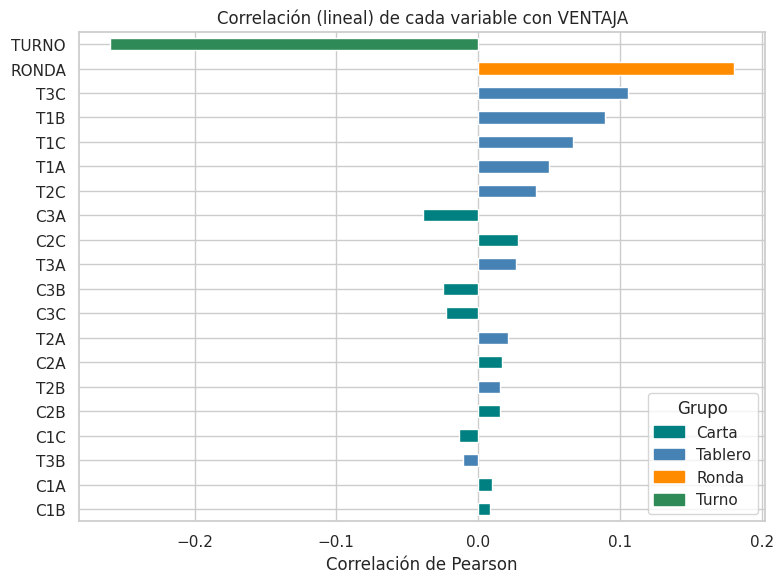

In [16]:
group_map = {}
for c in card_cols:      # C1A...C3C
    group_map[c] = "Carta"
for c in [c for c in feature_cols if c.startswith("T")]:
    group_map[c] = "Tablero"
group_map["RONDA"] = "Ronda"
group_map["TURNO"] = "Turno"

group_colors = {"Carta": "teal", "Tablero": "steelblue", "Ronda": "darkorange", "Turno": "seagreen"}
bar_colors = [group_colors[group_map[var]] for var in target_corr.index]

plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color=bar_colors)
plt.title("Correlación (lineal) de cada variable con VENTAJA")
plt.xlabel("Correlación de Pearson")
plt.gca().invert_yaxis()

# Leyenda manual (una barra no trae leyenda propia por color)
handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in group_colors.values()]
plt.legend(handles, group_colors.keys(), title="Grupo", loc="lower right")

plt.tight_layout()
plt.show()

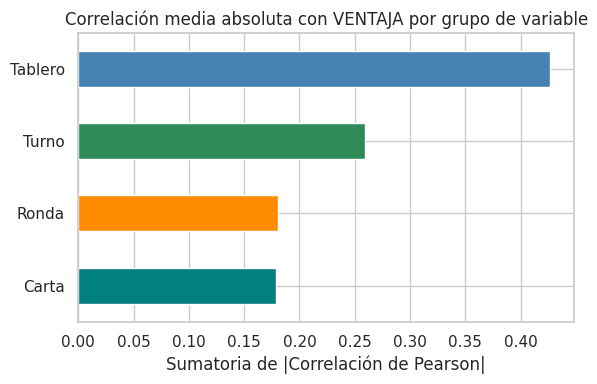

In [59]:
group_corr = (pd.Series({var: abs(val) for var, val in target_corr.items()})
    .groupby(group_map)
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(6, 4))
group_corr.plot(kind="barh", color=[group_colors[g] for g in group_corr.index])
plt.title("Correlación media absoluta con VENTAJA por grupo de variable")
plt.xlabel("Sumatoria de |Correlación de Pearson|")
plt.tight_layout()
plt.show()

In [18]:
group_corr = (pd.Series({var: abs(val) for var, val in target_corr.items()})
    .groupby(group_map)
    .sum()
    .sort_values(ascending=False)
)

group_corr

,0
Tablero,0.426950
Turno,0.259424
Ronda,0.180678
Carta,0.178748


## 2. Preprocesamiento de los datos

Puntos aplicados en base al análisis previo, adecuados al objetivo de clasificación:
- **Split estratificado por `VENTAJA`**: en clasificación, lo estándar es estratificar por la variable objetivo para que train y test mantengan la misma proporción de clases (relevante aquí porque hay un desbalance moderado ~60/40).
- Se verifica que la proporción de `RONDA` no quede muy distorsionada entre train y test.

In [19]:
X = df[feature_cols].copy()
y = df["VENTAJA"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,   # estratificación por VENTAJA para mantener el balance de clases
)

print("Train:", X_train.shape, " Test:", X_test.shape)

print("\nProporción de VENTAJA en el dataset completo:")
print(df["VENTAJA"].value_counts(normalize=True).sort_index())

print("\nProporción de VENTAJA en train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nProporción de VENTAJA en test:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en el dataset completo:")
print(df["RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en train:")
print(df.loc[X_train.index, "RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en test:")
print(df.loc[X_test.index, "RONDA"].value_counts(normalize=True).sort_index())

Train: (2325, 20)  Test: (582, 20)

Proporción de VENTAJA en el dataset completo:
VENTAJA
0    0.602683
1    0.397317
Name: proportion, dtype: float64

Proporción de VENTAJA en train:
VENTAJA
0    0.602581
1    0.397419
Name: proportion, dtype: float64

Proporción de VENTAJA en test:
VENTAJA
0    0.603093
1    0.396907
Name: proportion, dtype: float64

Proporción de RONDA en el dataset completo:
RONDA
1    0.214654
2    0.392501
3    0.209494
4    0.128655
5    0.054696
Name: proportion, dtype: float64

Proporción de RONDA en train:
RONDA
1    0.211183
2    0.397419
3    0.213763
4    0.121720
5    0.055914
Name: proportion, dtype: float64

Proporción de RONDA en test:
RONDA
1    0.228522
2    0.372852
3    0.192440
4    0.156357
5    0.049828
Name: proportion, dtype: float64


Para la validación cruzada durante el entrenamiento se usa `StratifiedKFold`, ya que en clasificación conviene preservar la proporción de clases en cada fold.

El split train/test ya garantiza la representatividad de `VENTAJA`, y en la sección de tuning se usa además `cross_validate` sobre el set de entrenamiento para tener una estimación robusta del desempeño.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Entrenamiento de los modelos

Como baselines de referencia se usan:
- `DummyClassifier` (predice siempre la clase mayoritaria)
- `LogisticRegression`

Se entrenan dos modelos base (parámetros por defecto / razonables, sin tuning todavía):

- `RandomForestClassifier`
- `XGBClassifier`

Se evalúan con validación cruzada estratificada de 5 folds sobre el set de entrenamiento, usando accuracy, precision, recall, F1 y ROC-AUC.

In [21]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

baseline_models = {
    "Dummy (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric="logloss",
    ),
}

def print_cv_summary(name, res):
    print(f"--- {name} (CV 5-fold estratificada sobre train) ---")
    print(f"Accuracy : {res['test_accuracy'].mean():.4f} +/- {res['test_accuracy'].std():.4f}")
    print(f"Precision: {res['test_precision'].mean():.4f} +/- {res['test_precision'].std():.4f}")
    print(f"Recall   : {res['test_recall'].mean():.4f} +/- {res['test_recall'].std():.4f}")
    print(f"F1       : {res['test_f1'].mean():.4f} +/- {res['test_f1'].std():.4f}")
    print(f"ROC-AUC  : {res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}")

baseline_cv_results = {}
for name, model in baseline_models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_cv_results[name] = res
    print_cv_summary(name, res)

cv_results = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = res
    print_cv_summary(name, res)

--- Dummy (clase mayoritaria) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.6026 +/- 0.0009
Precision: 0.0000 +/- 0.0000
Recall   : 0.0000 +/- 0.0000
F1       : 0.0000 +/- 0.0000
ROC-AUC  : 0.5000 +/- 0.0000
--- LogisticRegression (CV 5-fold estratificada sobre train) ---
Accuracy : 0.6284 +/- 0.0178
Precision: 0.5470 +/- 0.0325
Recall   : 0.3734 +/- 0.0527
F1       : 0.4423 +/- 0.0433
ROC-AUC  : 0.6568 +/- 0.0418
--- RandomForest (CV 5-fold estratificada sobre train) ---
Accuracy : 0.7738 +/- 0.0217
Precision: 0.7481 +/- 0.0359
Recall   : 0.6504 +/- 0.0269
F1       : 0.6957 +/- 0.0287
ROC-AUC  : 0.8385 +/- 0.0243
--- XGBoost (CV 5-fold estratificada sobre train) ---
Accuracy : 0.8013 +/- 0.0237
Precision: 0.7599 +/- 0.0277
Recall   : 0.7305 +/- 0.0405
F1       : 0.7447 +/- 0.0330
ROC-AUC  : 0.8733 +/- 0.0166


In [22]:
# Entrenamiento final de cada modelo
fitted_baselines = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    fitted_baselines[name] = model

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

## 4. Comparación de métricas para escoger el mejor modelo

Se evalúa cada modelo sobre el set de **test** (datos no vistos durante el entrenamiento ni la validación cruzada) y se comparan accuracy, precision, recall, F1 y ROC-AUC.

In [23]:
def evaluate(model, X_te, y_te):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds, zero_division=0),
        "Recall": recall_score(y_te, preds, zero_division=0),
        "F1": f1_score(y_te, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_te, proba),
    }

baseline_test_metrics = {
    name: evaluate(model, X_test, y_test) for name, model in fitted_baselines.items()
}

test_metrics = {
    name: evaluate(model, X_test, y_test) for name, model in fitted_models.items()
}

metrics_df = pd.DataFrame(test_metrics).T

full_metrics_df = pd.concat(
    [pd.DataFrame(baseline_test_metrics).T, metrics_df], axis=0
)
full_metrics_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Dummy (clase mayoritaria),0.603093,0.000000,0.000000,0.000000,0.500000
LogisticRegression,0.635739,0.559748,0.385281,0.456410,0.682959
RandomForest,0.812715,0.814433,0.683983,0.743529,0.887224
XGBoost,0.838488,0.821596,0.757576,0.788288,0.901629


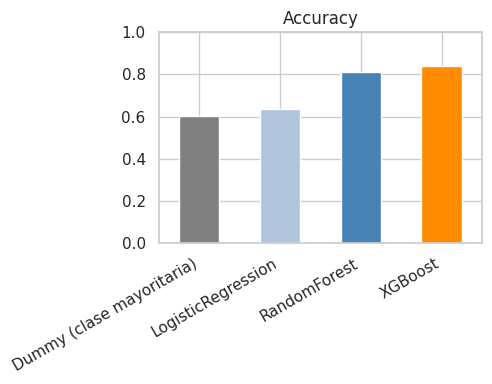

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Logistic, RF, XGBoost

full_metrics_df["Accuracy"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Accuracy")
ax.set_ylim(0, 1)
ax.set_xticklabels(full_metrics_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

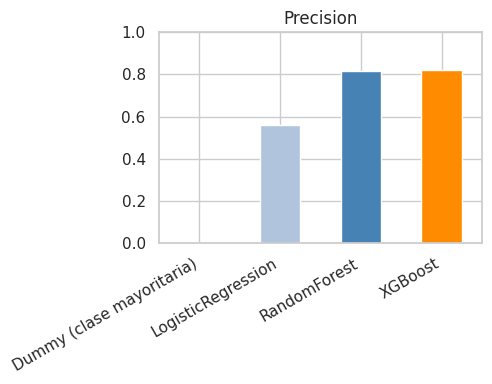

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]

full_metrics_df["Precision"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Precision")
ax.set_ylim(0, 1)
ax.set_xticklabels(full_metrics_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

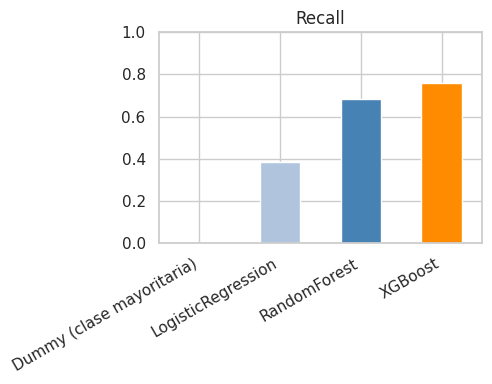

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]

full_metrics_df["Recall"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Recall")
ax.set_ylim(0, 1)
ax.set_xticklabels(full_metrics_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

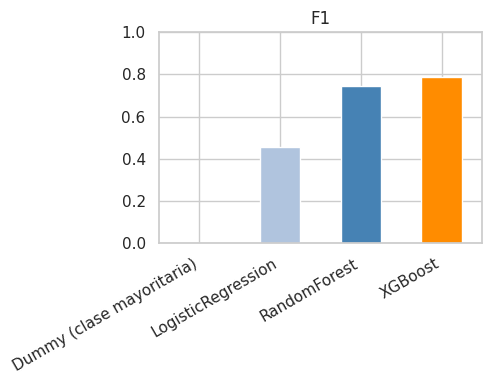

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]

full_metrics_df["F1"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("F1")
ax.set_ylim(0, 1)
ax.set_xticklabels(full_metrics_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

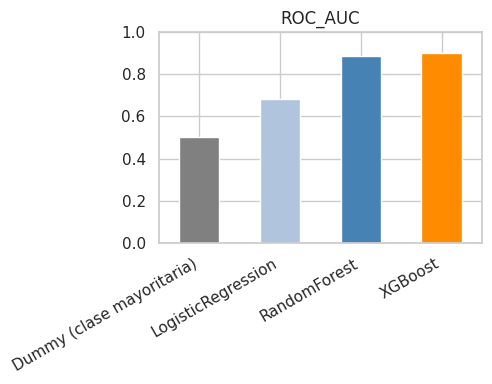

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]

full_metrics_df["ROC_AUC"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("ROC_AUC")
ax.set_ylim(0, 1)
ax.set_xticklabels(full_metrics_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Matrices de confusión y curvas ROC (ambos modelos)

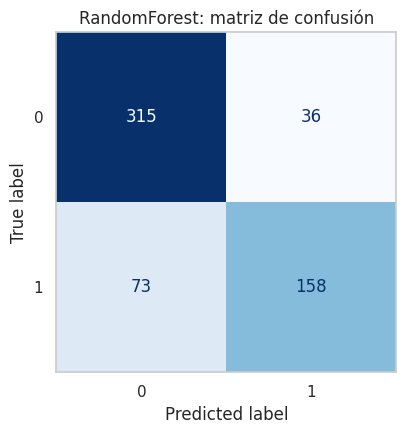

In [60]:
name_rf, model_rf = list(fitted_models.items())[0]  # RandomForest

fig, ax = plt.subplots(figsize=(5, 4.5))
preds_rf = model_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, preds_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{name_rf}: matriz de confusión")
ax.grid(False)
plt.tight_layout()
plt.show()

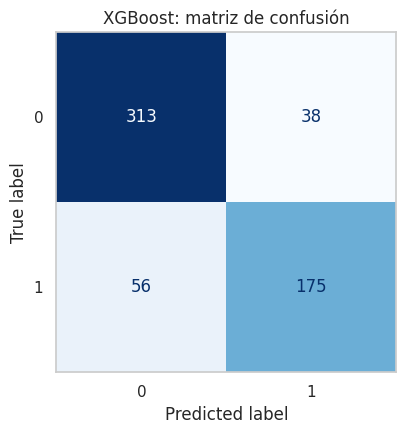

In [61]:
name_xgb, model_xgb = list(fitted_models.items())[1]  # XGBoost

fig, ax = plt.subplots(figsize=(5, 4.5))
preds_xgb = model_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, preds_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{name_xgb}: matriz de confusión")
ax.grid(False)
plt.tight_layout()
plt.show()

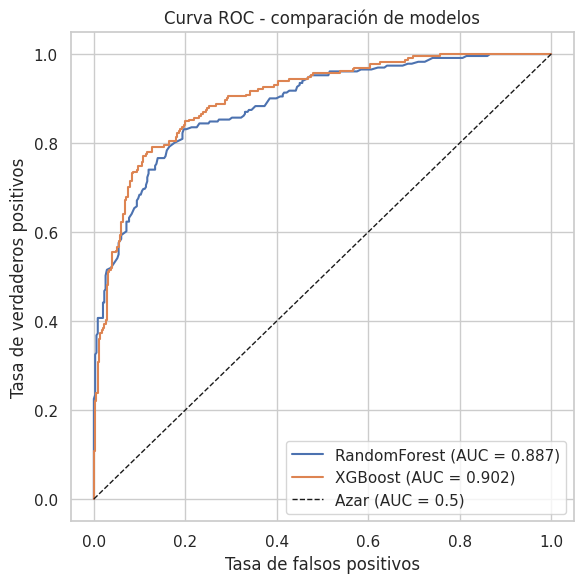

In [31]:
plt.figure(figsize=(6, 6))
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - comparación de modelos")
plt.legend()
plt.tight_layout()
plt.show()

### Reporte de clasificación detallado

Se muestra `classification_report` de cada modelo, con precision/recall/F1 por clase
(útil dado el desbalance moderado de `VENTAJA`).

In [32]:
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=["VENTAJA=0", "VENTAJA=1"]))

--- RandomForest ---
              precision    recall  f1-score   support

   VENTAJA=0       0.81      0.90      0.85       351
   VENTAJA=1       0.81      0.68      0.74       231

    accuracy                           0.81       582
   macro avg       0.81      0.79      0.80       582
weighted avg       0.81      0.81      0.81       582

--- XGBoost ---
              precision    recall  f1-score   support

   VENTAJA=0       0.85      0.89      0.87       351
   VENTAJA=1       0.82      0.76      0.79       231

    accuracy                           0.84       582
   macro avg       0.83      0.82      0.83       582
weighted avg       0.84      0.84      0.84       582



### Importancia de variables (modelos base)

Recordar que, por la multicolinealidad documentada en el EDA entre algunas variables
`T*`, el reparto de importancia entre variables correlacionadas puede ser algo
arbitrario; se interpreta a nivel de grupos de variables más que de una sola celda.

In [33]:
name_rf, model_rf = list(fitted_models.items())[0]  # RandomForest
importances_rf_full = pd.Series(model_rf.feature_importances_, index=feature_cols)
group_importance_rf = importances_rf_full.groupby(group_map).sum().sort_values(ascending=False)

group_importance_rf

,0
Carta,0.580431
Tablero,0.341653
Turno,0.042110
Ronda,0.035806


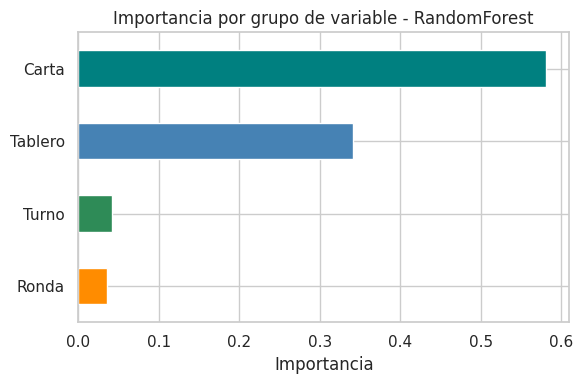

In [62]:
group_importance_rf = importances_rf_full.groupby(group_map).sum().sort_values(ascending=True)

plt.figure(figsize=(6, 4))
group_importance_rf.plot(kind="barh", color=[group_colors[g] for g in group_importance_rf.index])
plt.title(f"Importancia por grupo de variable - {name_rf}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [35]:
name_xgb, model_xgb = list(fitted_models.items())[1]  # XGBoost
importances_xgb_full = pd.Series(model_xgb.feature_importances_, index=feature_cols)
group_importance_xgb = importances_xgb_full.groupby(group_map).sum().sort_values(ascending=False)

group_importance_xgb

,0
Tablero,0.411076
Carta,0.342925
Turno,0.180885
Ronda,0.065113


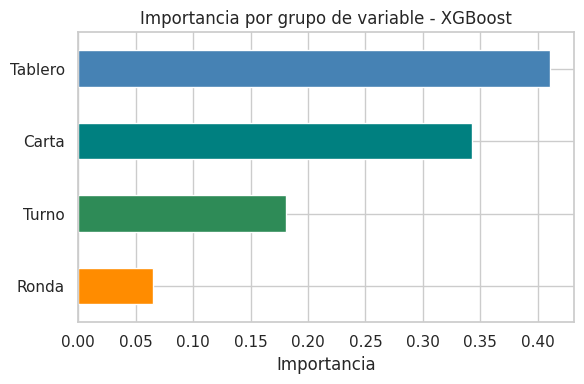

In [64]:
group_importance_xgb = importances_xgb_full.groupby(group_map).sum().sort_values(ascending=True)

plt.figure(figsize=(6, 4))
group_importance_xgb.plot(kind="barh", color=[group_colors[g] for g in group_importance_xgb.index])
plt.title(f"Importancia por grupo de variable - {name_xgb}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [37]:
best_model_name = metrics_df["ROC_AUC"].idxmax()
print(f"Modelo ganador según ROC-AUC en test: {best_model_name}")
metrics_df.loc[[best_model_name]]

Modelo ganador según ROC-AUC en test: XGBoost


,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.838488,0.821596,0.757576,0.788288,0.901629


## 5. Tuning del modelo ganador

Se realiza una búsqueda de hiperparámetros con `RandomizedSearchCV` (más eficiente que un
`GridSearchCV` exhaustivo dado el tamaño del espacio de búsqueda), usando
`StratifiedKFold` de 5 particiones sobre el set de entrenamiento y ROC-AUC como métrica
objetivo (más robusta que accuracy frente al desbalance de clases).

**Nota:** la celda de abajo elige automáticamente la grilla según cuál haya sido el
modelo ganador (`XGBoost` o `RandomForest`), igual que en el notebook original.

In [38]:
if best_model_name == "XGBoost":
    param_distributions = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
        "reg_alpha": [0, 0.01, 0.1, 1],
        "reg_lambda": [1, 1.5, 2, 5],
    }
    base_estimator = XGBClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"
    )
else:
    param_distributions = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5, None],
    }
    base_estimator = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search.best_score_)
print("Mejores hiperparámetros:")
search.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor ROC-AUC en CV: 0.8759177760904514
Mejores hiperparámetros:


{'subsample': 0.8,
 'reg_lambda': 1.5,
 'reg_alpha': 0,
 'n_estimators': 800,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

In [39]:
tuned_model = search.best_estimator_
tuned_metrics = evaluate(tuned_model, X_test, y_test)

print(f"Métricas del modelo {best_model_name} tuneado (test):")
for metric_name, value in tuned_metrics.items():
    print(f"  {metric_name:9s}: {value:.4f}")

Métricas del modelo XGBoost tuneado (test):
  Accuracy : 0.8419
  Precision: 0.8390
  Recall   : 0.7446
  F1       : 0.7890
  ROC_AUC  : 0.9110


In [40]:
comparison = pd.DataFrame(
    {
        f"{best_model_name} (base)": test_metrics[best_model_name],
        f"{best_model_name} (tuned)": tuned_metrics,
    }
).T

# Variación absoluta del modelo tuneado respecto al base para cada métrica
for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    comparison[f"{metric}_delta"] = comparison[metric] - comparison[metric].iloc[0]

comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,Accuracy_delta,Precision_delta,Recall_delta,F1_delta,ROC_AUC_delta
XGBoost (base),0.838488,0.821596,0.757576,0.788288,0.901629,0.000000,0.000000,0.000000,0.000000,0.000000
XGBoost (tuned),0.841924,0.839024,0.744589,0.788991,0.911027,0.003436,0.017428,-0.012987,0.000703,0.009398


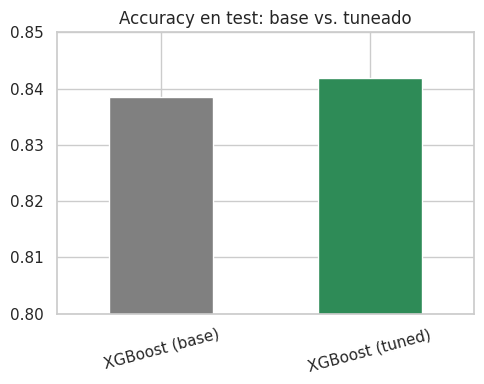

In [65]:
fig, ax = plt.subplots(figsize=(5, 4))
comparison["Accuracy"].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
ax.set_title("Accuracy en test: base vs. tuneado")
ax.set_ylim(0.8, 0.85)
ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()

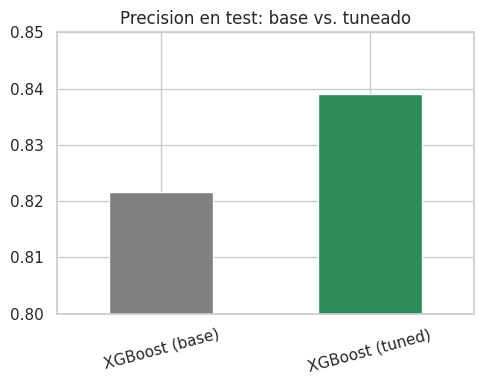

In [66]:
fig, ax = plt.subplots(figsize=(5, 4))
comparison["Precision"].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
ax.set_title("Precision en test: base vs. tuneado")
ax.set_ylim(0.8, 0.85)
ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()

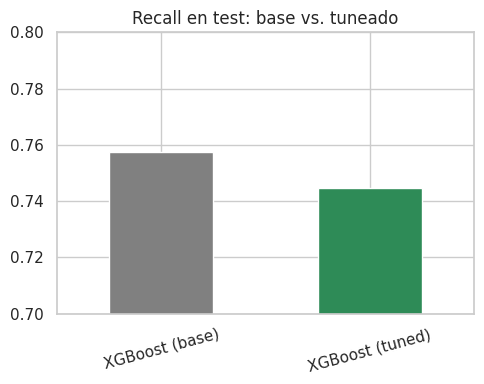

In [67]:
fig, ax = plt.subplots(figsize=(5, 4))
comparison["Recall"].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
ax.set_title("Recall en test: base vs. tuneado")
ax.set_ylim(0.7, 0.8)
ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()

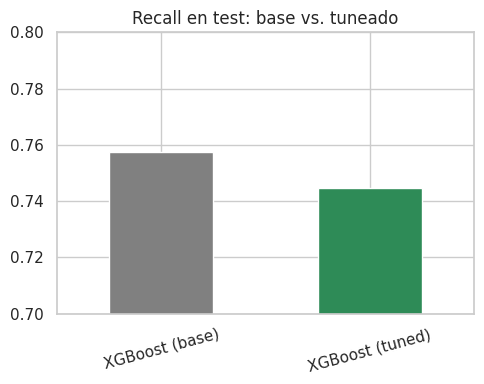

In [68]:
fig, ax = plt.subplots(figsize=(5, 4))
comparison["Recall"].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
ax.set_title("Recall en test: base vs. tuneado")
ax.set_ylim(0.7, 0.8)
ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()

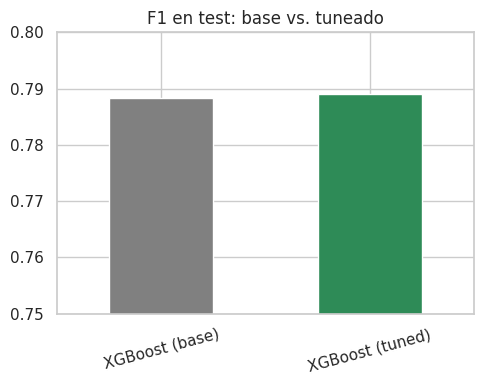

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
comparison["F1"].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
ax.set_title("F1 en test: base vs. tuneado")
ax.set_ylim(0.75, 0.8)
ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()

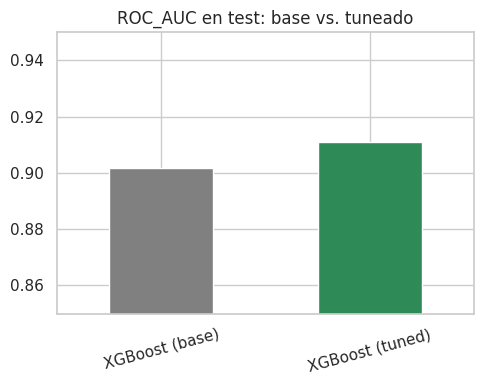

In [71]:
fig, ax = plt.subplots(figsize=(5, 4))
comparison["ROC_AUC"].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
ax.set_title("ROC_AUC en test: base vs. tuneado")
ax.set_ylim(0.85, 0.95)
ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()

### Matriz de confusión y curva ROC del modelo final

In [47]:
preds_tuned = tuned_model.predict(X_test)
proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

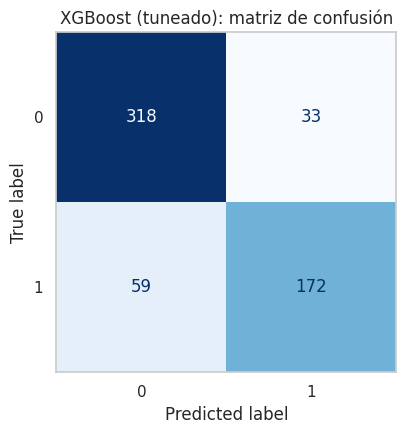

In [72]:
fig, ax = plt.subplots(figsize=(5, 4.5))

cm = confusion_matrix(y_test, preds_tuned)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{best_model_name} (tuneado): matriz de confusión")
ax.grid(False)
plt.tight_layout()
plt.show()

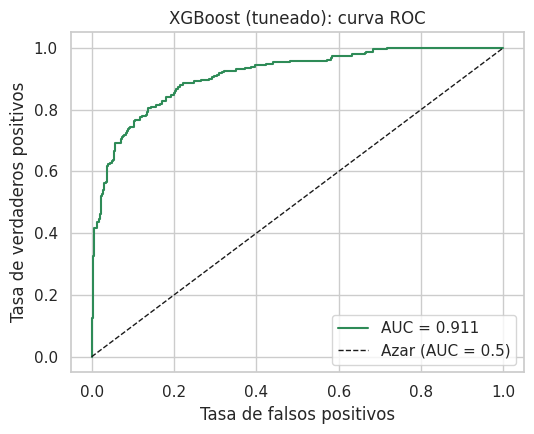

In [49]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

fpr, tpr, _ = roc_curve(y_test, proba_tuned)
auc = roc_auc_score(y_test, proba_tuned)
ax.plot(fpr, tpr, color="seagreen", label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title(f"{best_model_name} (tuneado): curva ROC")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Interpretabilidad con SHAP (modelo tuneado)

SHAP (SHapley Additive exPlanations) da una explicación consistente:

- Es **aditivo**: la suma de los SHAP values de una fila más el valor base reconstruye exactamente el logit (o la probabilidad, según la convención del explainer) de `VENTAJA=1` para esa fila.
- Muestra **dirección** del efecto (si un valor alto de la variable empuja la probabilidad de `VENTAJA=1` hacia arriba o hacia abajo), no solo cuánto "importa" en promedio.
- Permite explicaciones tanto **globales** (todo el dataset) como **locales** (una jugada puntual).

Se usa `TreeExplainer`, que es exacto y eficiente para modelos basados en árboles como Random Forest y XGBoost. Para clasificación binaria, según la versión de SHAP y del modelo, el explainer puede devolver los valores para ambas clases; se normaliza para quedarnos siempre con los SHAP values de la clase positiva (`VENTAJA=1`).

In [50]:
# Si no está instalado: !pip install shap --quiet
import shap

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer(X_test)

# Para clasificación binaria, algunos modelos/backends devuelven un array
# (n_muestras, n_features, n_clases); nos quedamos con la clase positiva (VENTAJA=1).
if shap_values.values.ndim == 3:
    shap_values = shap_values[..., 1]

print("Shape de shap_values.values:", shap_values.values.shape)

Shape de shap_values.values: (582, 20)


### 6.1 Importancia global de variables (SHAP summary plot - barras)

In [51]:
sum_abs_shap = pd.Series(np.abs(shap_values.values).sum(axis=0), index=feature_cols)
group_shap = sum_abs_shap.groupby(group_map).sum().sort_values(ascending=False)

group_shap

,0
Tablero,1757.956909
Carta,1610.724487
Turno,498.211182
Ronda,211.022812


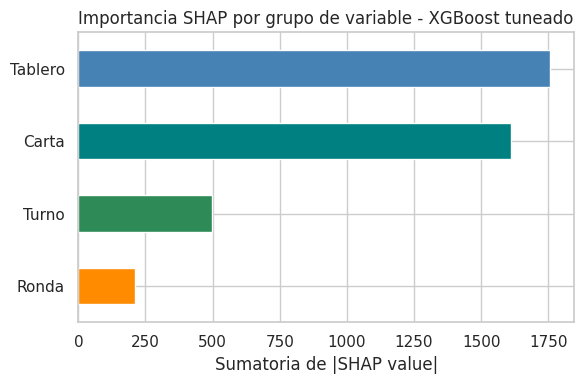

In [73]:
group_shap = sum_abs_shap.groupby(group_map).sum().sort_values(ascending=True)
plt.figure(figsize=(6, 4))
group_shap.plot(kind="barh", color=[group_colors[g] for g in group_shap.index])
plt.title(f"Importancia SHAP por grupo de variable - {best_model_name} tuneado")
plt.xlabel("Sumatoria de |SHAP value|")
plt.tight_layout()
plt.show()

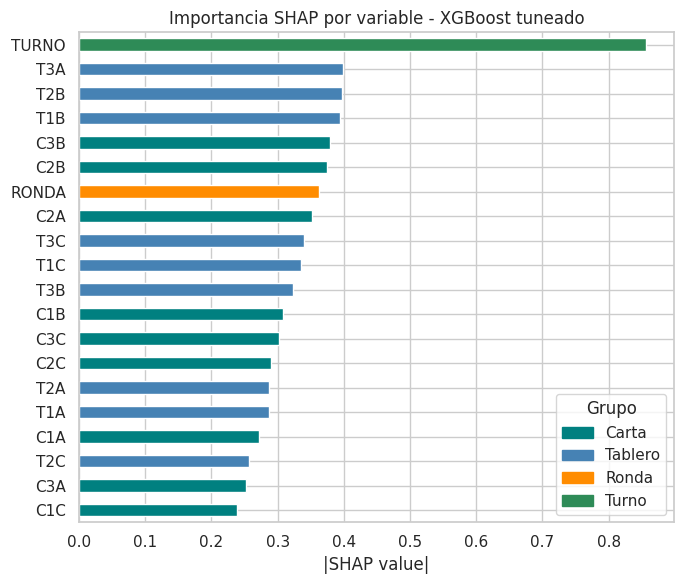

In [74]:
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols)
mean_abs_shap_sorted = mean_abs_shap.sort_values(ascending=True)
bar_colors_shap = [group_colors[group_map[var]] for var in mean_abs_shap_sorted.index]

plt.figure(figsize=(7, 6))
mean_abs_shap_sorted.plot(kind="barh", color=bar_colors_shap)
plt.title(f"Importancia SHAP por variable - {best_model_name} tuneado")
plt.xlabel("|SHAP value|")

handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in group_colors.values()]
plt.legend(handles, group_colors.keys(), title="Grupo", loc="lower right")

plt.tight_layout()
plt.show()

### 6.2 Distribución e impacto por variable (SHAP summary plot - beeswarm)

Cada punto es una fila del set de test. La posición en el eje X indica si esa variable
empujó la predicción hacia `VENTAJA=1` o hacia `VENTAJA=0` para esa fila, y el color
indica si el valor de la variable era alto (rojo) o bajo (azul).

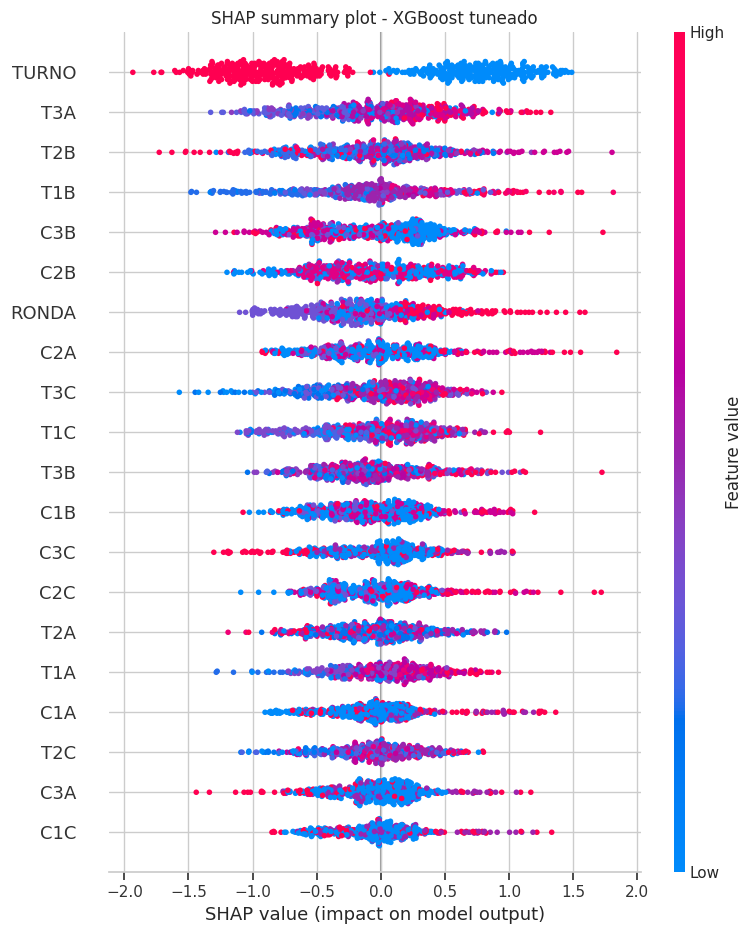

In [54]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP summary plot - {best_model_name} tuneado")
plt.tight_layout()
plt.show()

### 6.3 Dependence plots de las variables más importantes

Se inspeccionan con más detalle las variables que resultaron más influyentes, viendo cómo
el SHAP value de cada una varía según su propio valor y, opcionalmente, coloreado por una
segunda variable con la que pueda interactuar.

Top 3 variables según SHAP: ['TURNO', 'T3A', 'T2B']


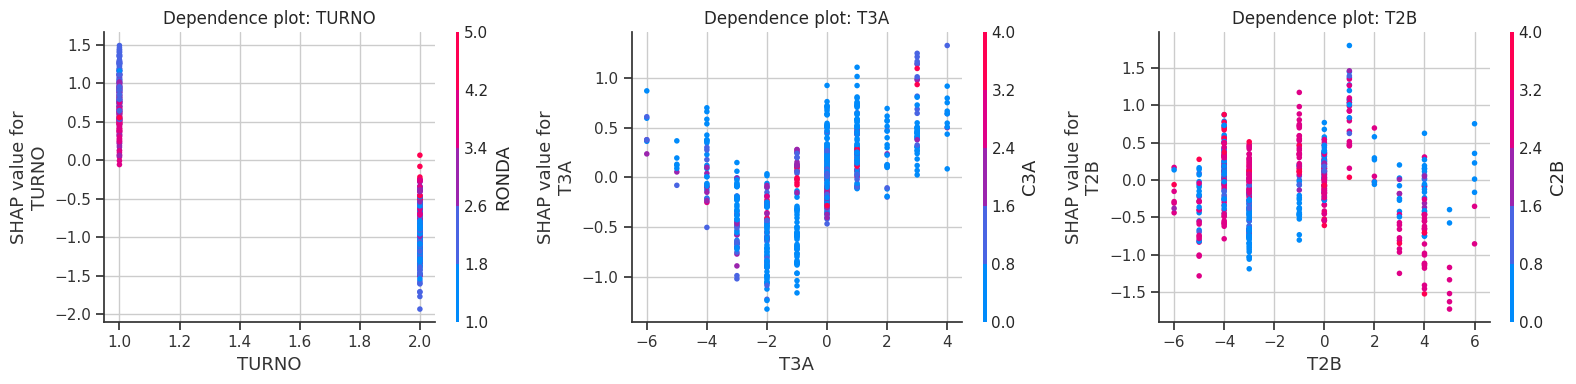

In [55]:
top_features = (
    pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print("Top 3 variables según SHAP:", top_features)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, shap_values.values, X_test, ax=ax, show=False)
    ax.set_title(f"Dependence plot: {feat}")
plt.tight_layout()
plt.show()

### 6.4 Explicación local de un caso puntual

Ejemplo de cómo SHAP explica la predicción de una jugada individual del set de test: qué
variables la empujaron hacia `VENTAJA=1` o hacia `VENTAJA=0` respecto al valor base.

VENTAJA real: 1
Probabilidad predicha de VENTAJA=1: 0.9571
Clase predicha: 1


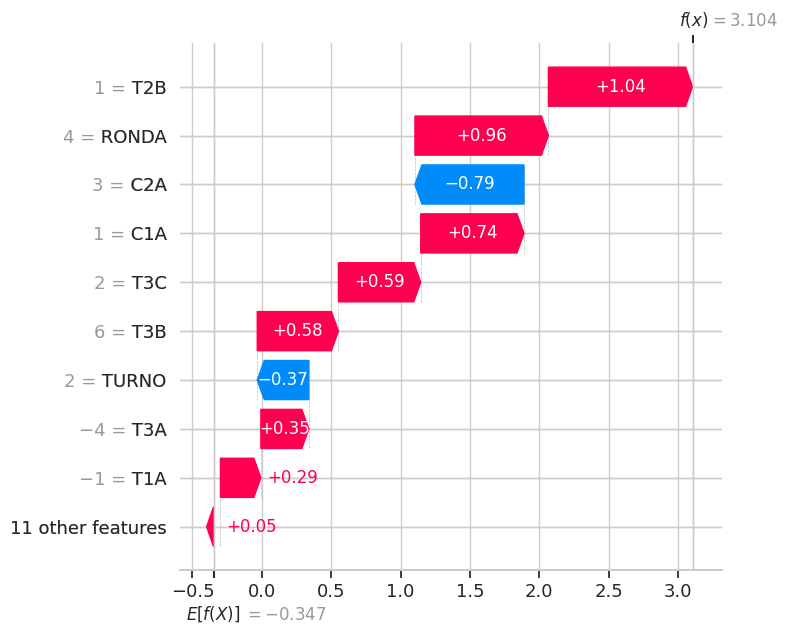

In [56]:
idx = 0  # cambiar el índice para inspeccionar otra jugada del set de test
proba_idx = tuned_model.predict_proba(X_test.iloc[[idx]])[0, 1]
print(f"VENTAJA real: {y_test.iloc[idx]}")
print(f"Probabilidad predicha de VENTAJA=1: {proba_idx:.4f}")
print(f"Clase predicha: {int(proba_idx >= 0.5)}")

shap.plots.waterfall(shap_values[idx], show=False)
plt.tight_layout()
plt.show()

### Conclusiones

- El modelo ganador y sus métricas finales quedan resumidos en la tabla de la sección 4
  (`metrics_df`) y en la comparación base vs. tuneado de esta sección (`comparison`).
- Al ser `VENTAJA` una variable binaria con desbalance moderado (~60/40), ROC-AUC y F1 son
  más informativas que accuracy para juzgar el desempeño real del modelo.
- Un ROC-AUC muy cercano a 1 en test reforzaría la hipótesis de que `VENTAJA` tiene un
  fuerte componente determinístico calculable a partir del estado del tablero y la carta
  jugada, más que una relación ruidosa que dependa de factores no observados.
- Antes de llevar el modelo a producción, se recomienda:
  1. Repetir esta evaluación con más partidas simuladas, en particular de rondas 4 y 5,
     para confirmar que el desempeño se mantiene en esa región poco representada.
  2. Revisar el umbral de decisión (por defecto 0.5) según el costo relativo de falsos
     positivos vs. falsos negativos en el caso de uso concreto.
  3. Guardar el modelo final (`tuned_model`) y los hiperparámetros usados para
     reproducibilidad.

In [57]:
# Guardar el modelo final (opcional)
import joblib
joblib.dump(tuned_model, "modelo_final_ventaja.pkl")
print("Modelo guardado en modelo_final_ventaja.pkl")

Modelo guardado en modelo_final_ventaja.pkl
